# Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Exploring the Data

In [35]:
df = pd.read_excel("D:\Assesment- Daniela García Pedidos YA\Clusters and Overview.xlsx", sheet_name="Original DB", index_col=0)

In [36]:
df.head()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit
ID,,,,,,,,,,,
1,134,0,124,8.0,0,0,0.0,0.0,0.0,0,-32
2,116,0,276,-20.0,0,0,0.0,0.0,0.0,0,-66
3,114,0,360,-10.0,2,2,3.0,3.0,26.0,-2,1814
4,112,0,156,-74.0,0,0,0.0,0.0,-14.0,0,60
5,110,0,236,126.0,0,0,0.0,0.0,10.0,2,1990


In [37]:
df.isnull().sum()

Subscription Months               0
Churn                             0
IS                                0
Var IS                            1
Number of Support Cases           0
Var in Number of Support Cases    0
Support Priority                  1
Var in Support Priority           0
Vro Nro Logins                    1
Var in Service Usage              0
Var in Customer Benefit           0
dtype: int64

In [38]:
df = df.dropna()

In [39]:
#Removing the row where Churn = 4, as these are likely data entry errors
df = df[df['Churn'] != 4]

In [40]:
#Correlation among variables
df.corr()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit
Subscription Months,1.000000,0.026886,0.286057,-0.182786,-0.114580,-0.060854,-0.081438,-0.026202,-0.058627,-0.039264,-0.013055
Churn,0.026886,1.000000,-0.081916,-0.046231,-0.025090,0.028632,-0.041975,0.020979,-0.045382,-0.012727,-0.018592
IS,0.286057,-0.081916,1.000000,0.184928,0.307475,0.011580,0.369041,-0.007277,0.330808,0.035269,0.067715
Var IS,-0.182786,-0.046231,0.184928,1.000000,0.264552,0.287970,0.227142,0.238547,0.458215,0.094604,0.056413
Number of Support Cases,-0.114580,-0.025090,0.307475,0.264552,1.000000,0.461935,0.685475,0.285265,0.343467,0.022441,0.019400
Var in Number of Support Cases,-0.060854,0.028632,0.011580,0.287970,0.461935,1.000000,0.271130,0.465984,0.264624,0.040815,0.056220
Support Priority,-0.081438,-0.041975,0.369041,0.227142,0.685475,0.271130,1.000000,0.557636,0.303914,0.059852,0.050917
Var in Support Priority,-0.026202,0.020979,-0.007277,0.238547,0.285265,0.465984,0.557636,1.000000,0.228287,0.015913,0.012585
Vro Nro Logins,-0.058627,-0.045382,0.330808,0.458215,0.343467,0.264624,0.303914,0.228287,1.000000,0.036738,0.003166
Var in Service Usage,-0.039264,-0.012727,0.035269,0.094604,0.022441,0.040815,0.059852,0.015913,0.036738,1.000000,0.754977


In [41]:
#Correlation Matrix-calculation
corr_matrix = df.corr(numeric_only=True)

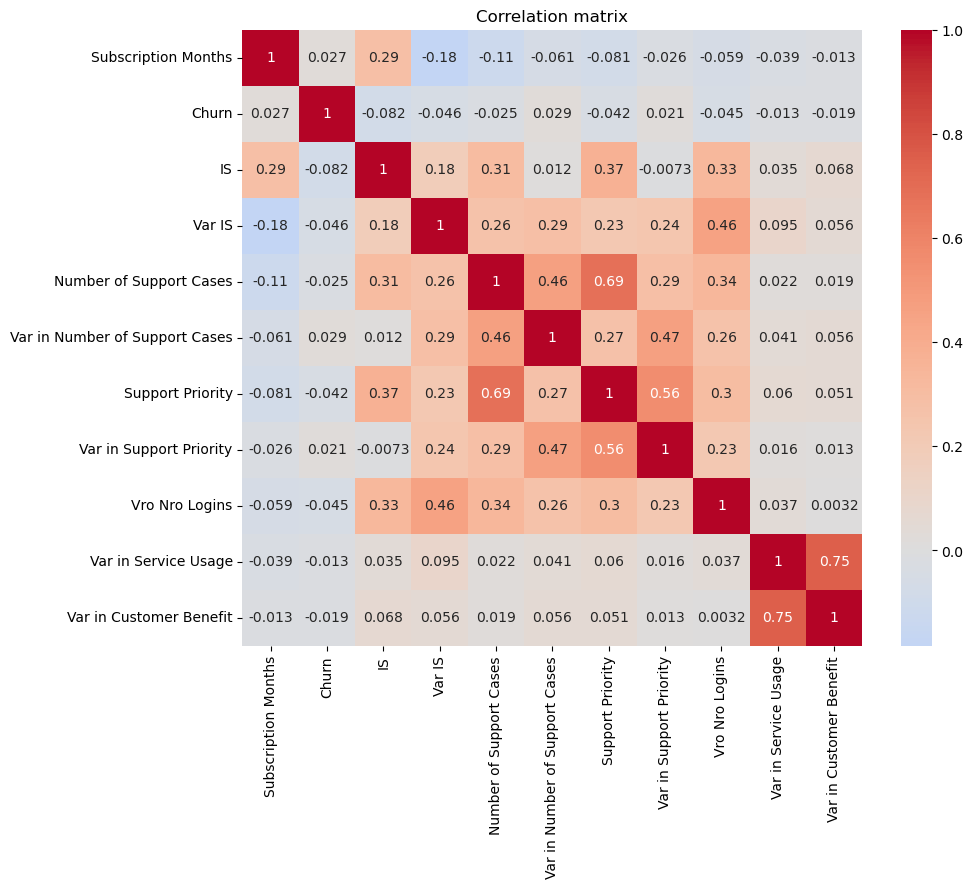

In [42]:
#Visualizing correlation matrix in a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2002 entries, 1 to 2012
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Subscription Months             2002 non-null   int64  
 1   Churn                           2002 non-null   int64  
 2   IS                              2002 non-null   int64  
 3   Var IS                          2002 non-null   float64
 4   Number of Support Cases         2002 non-null   int64  
 5   Var in Number of Support Cases  2002 non-null   int64  
 6   Support Priority                2002 non-null   float64
 7   Var in Support Priority         2002 non-null   float64
 8   Vro Nro Logins                  2002 non-null   float64
 9   Var in Service Usage            2002 non-null   int64  
 10  Var in Customer Benefit         2002 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 187.7 KB


In [44]:
#Describing the database
df.describe()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit
count,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000,2002.000000
mean,27.976024,0.043956,174.032967,9.319680,1.355644,0.113886,0.809982,0.047520,29.341658,159.202797,285.998002
std,22.491654,0.205049,131.890482,62.214656,3.234372,3.573322,1.322589,1.431072,75.941218,2680.141486,3540.752024
min,0.000000,0.000000,0.000000,-250.000000,0.000000,-32.000000,0.000000,-4.000000,-224.000000,-86.000000,-25950.000000
25%,10.000000,0.000000,50.000000,-16.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,0.000000,-38.000000
50%,22.000000,0.000000,176.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000
75%,42.000000,0.000000,275.500000,28.000000,2.000000,0.000000,2.500000,0.000000,44.000000,0.000000,46.000000
max,134.000000,1.000000,580.000000,354.000000,36.000000,30.000000,6.000000,4.000000,706.000000,45506.000000,45577.000000


# Standardization of variables

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
columns_to_scale = [
    'Subscription Months',
    'IS',
    'Var IS',
    'Number of Support Cases',
    'Var in Number of Support Cases',
    'Support Priority',
    'Var in Support Priority',
    'Vro Nro Logins',
    'Var in Service Usage',
    'Var in Customer Benefit'
]

In [48]:
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [49]:
df.head()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit
ID,,,,,,,,,,,
1,4.715103,0,-0.379447,-0.021217,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.089833
2,3.914606,0,0.773312,-0.471384,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.099438
3,3.825662,0,1.410363,-0.310610,0.199271,0.527964,1.656270,2.063641,-0.044014,-0.060162,0.431655
4,3.736718,0,-0.136761,-1.339564,-0.419242,-0.031879,-0.612574,-0.033214,-0.570869,-0.059416,-0.063844
5,3.647774,0,0.469954,1.875916,-0.419242,-0.031879,-0.612574,-0.033214,-0.254756,-0.058669,0.481374


# Data Visualization

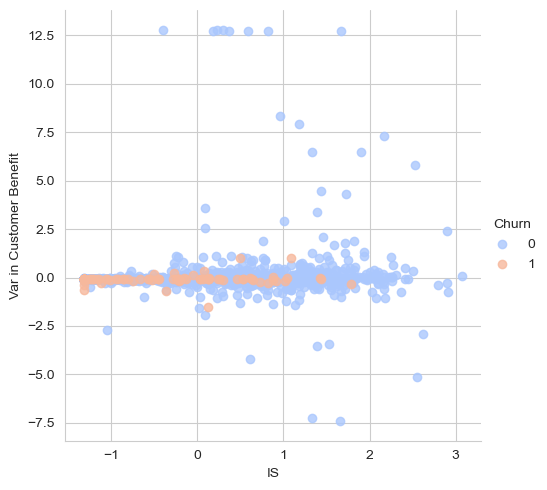

In [51]:
sns.set_style('whitegrid')
sns.lmplot(x='IS',y='Var in Customer Benefit',data=df, hue='Churn',
           palette='coolwarm',aspect=1,fit_reg=False)

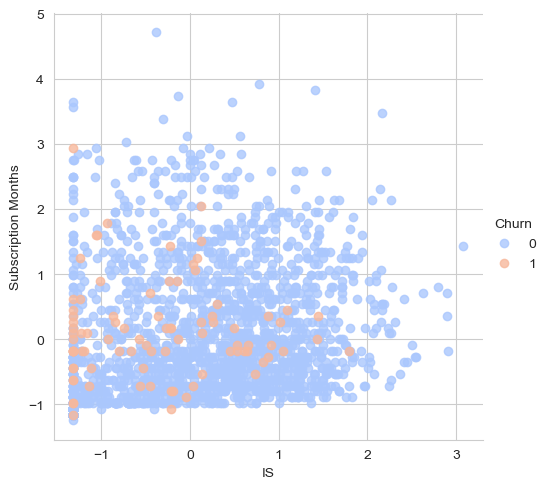

In [53]:
sns.set_style('whitegrid')
sns.lmplot(x='IS',y='Subscription Months',data=df, hue='Churn',
           palette='coolwarm',aspect=1,fit_reg=False)

# Creación de los clústers

In [56]:
#Importando KMeans

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [58]:
#Defining the optimal number of clusters

In [59]:
#Defining the optimal level of clusters
def optimise_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)

    # Generate the elbow plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(means, inertias, 'o-')
    ax.set_xlabel('Number of Clusters', fontsize=12)
    ax.set_ylabel('Inertia', fontsize=12)
    ax.set_title('Elbow Method for Optimal k', fontsize=14)
    ax.grid(True)
    plt.show()


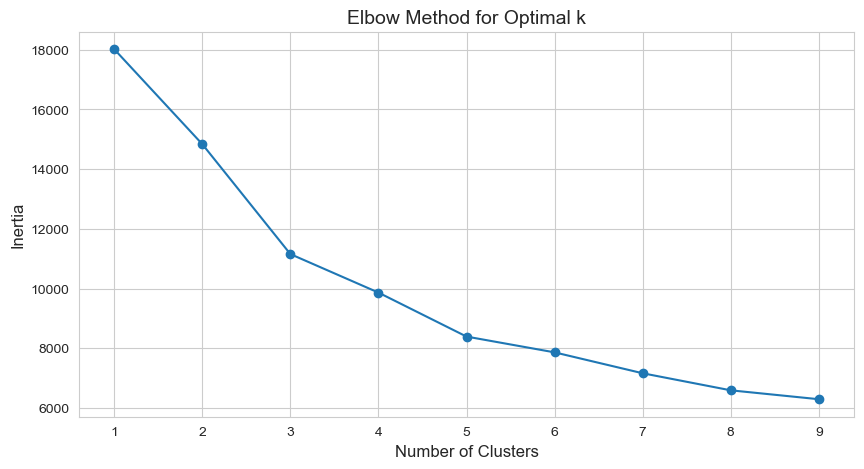

In [60]:
optimise_k_means(df.drop(['Churn','Var in Support Priority'], axis=1), 10)

In [61]:
#The optimal number of clusters is approximately 2-3 clusters

In [62]:
#3 clusters
kmeans3 = KMeans(n_clusters=3)
#It is generally recommended to use an odd number of clusters as they tend to fit the data better.

In [63]:
kmeans3.fit(df.drop(['Churn','Var in Support Priority'],axis=1))

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [64]:
#Centroids
kmeans3.cluster_centers_

array([[ 5.27132139e-02, -2.42609197e-01, -1.65667650e-01,
        -4.16660851e-01, -1.72423918e-01, -6.11522328e-01,
        -2.18631037e-01, -5.93062110e-02, -5.40933785e-02],
       [-5.26506220e-01,  7.69260426e-01,  1.62880864e+00,
         2.24968275e+00,  1.82403888e+00,  1.45701265e+00,
         1.88423819e+00, -5.84954952e-02, -1.59617664e-01],
       [ 2.55575717e-03,  5.65933022e-01,  1.01440028e-03,
         6.47618713e-01, -4.39332117e-02,  1.59484512e+00,
         9.40015688e-02,  2.24456157e-01,  2.41843199e-01]])

In [65]:
#Adding cluster classification variable to the data frame
df['k_means3']= kmeans3.labels_

In [66]:
df.head()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit,k_means3
ID,,,,,,,,,,,,
1,4.715103,0,-0.379447,-0.021217,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.089833,0
2,3.914606,0,0.773312,-0.471384,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.099438,0
3,3.825662,0,1.410363,-0.310610,0.199271,0.527964,1.656270,2.063641,-0.044014,-0.060162,0.431655,2
4,3.736718,0,-0.136761,-1.339564,-0.419242,-0.031879,-0.612574,-0.033214,-0.570869,-0.059416,-0.063844,0
5,3.647774,0,0.469954,1.875916,-0.419242,-0.031879,-0.612574,-0.033214,-0.254756,-0.058669,0.481374,0


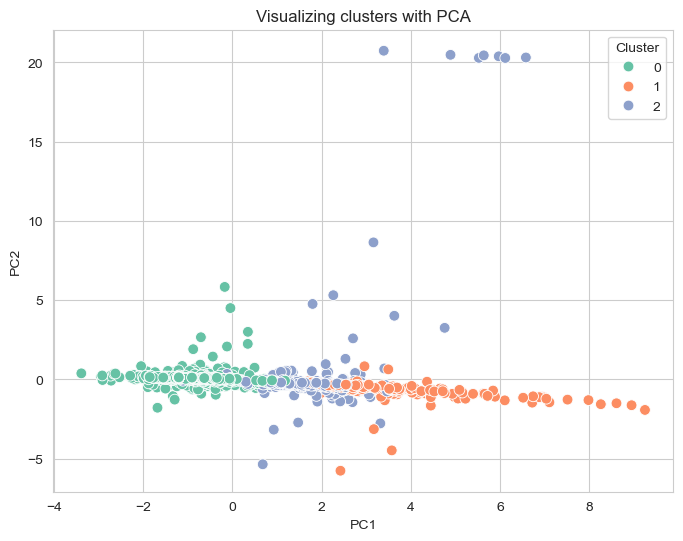

In [68]:
#Visualizing clusters with PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Data used to train KMeans
X = df.drop(['Churn','Var in Support Priority'], axis=1)

# Dimensionality reduction to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Adding results to the DataFrame
df_plot = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_plot['Cluster'] = kmeans3.labels_

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title('Visualizing clusters with PCA')
plt.show()

In [69]:
#Exportando Excel con clasificación de clientes
df.to_excel('clients_with_clusters.xlsx', index=True)

# Logistic Regression

In [70]:
df.head()

,Subscription Months,Churn,IS,Var IS,Number of Support Cases,Var in Number of Support Cases,Support Priority,Var in Support Priority,Vro Nro Logins,Var in Service Usage,Var in Customer Benefit,k_means3
ID,,,,,,,,,,,,
1,4.715103,0,-0.379447,-0.021217,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.089833,0
2,3.914606,0,0.773312,-0.471384,-0.419242,-0.031879,-0.612574,-0.033214,-0.386470,-0.059416,-0.099438,0
3,3.825662,0,1.410363,-0.310610,0.199271,0.527964,1.656270,2.063641,-0.044014,-0.060162,0.431655,2
4,3.736718,0,-0.136761,-1.339564,-0.419242,-0.031879,-0.612574,-0.033214,-0.570869,-0.059416,-0.063844,0
5,3.647774,0,0.469954,1.875916,-0.419242,-0.031879,-0.612574,-0.033214,-0.254756,-0.058669,0.481374,0


In [71]:
X= df.drop('Churn', axis=1)
y= df['Churn']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=101)


In [72]:
from sklearn.linear_model import LogisticRegression
logmodel=LogisticRegression()
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)

In [73]:
#Reporte de clasificación del modelo logístico
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       572
           1       0.00      0.00      0.00        29

    accuracy                           0.95       601
   macro avg       0.48      0.50      0.49       601
weighted avg       0.91      0.95      0.93       601



D:\ANACONDAINS\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ANACONDAINS\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\ANACONDAINS\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [74]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[572,   0],
       [ 29,   0]])

In [76]:
#Logistic Equation

# Intercept (β₀)
intercepto = logmodel.intercept_[0]

# Coefficients (β₁, β₂, …)
coeficientes = logmodel.coef_[0]

# Names of the variables
variables = X.columns

# Showing the equation
print("Logistic Equation:")
ecuacion = f"logit(p) = {intercepto:.4f}"
for var, coef in zip(variables, coeficientes):
    signo = '+' if coef >= 0 else ''
    ecuacion += f" {signo}{coef:.4f}*{var}"
print(ecuacion)


Logistic Equation:
logit(p) = -3.4614 +0.1699*Subscription Months -0.2486*IS -0.1114*Var IS +0.1061*Number of Support Cases +0.2084*Var in Number of Support Cases -0.6009*Support Priority +0.2969*Var in Support Priority -0.2563*Vro Nro Logins -0.0605*Var in Service Usage -0.2150*Var in Customer Benefit +0.3262*k_means3


In [77]:
odds_ratios = np.exp(logmodel.coef_[0])
print(odds_ratios)


[1.18516663 0.77987075 0.89456802 1.11198631 1.23172743 0.54829694
 1.34573073 0.77393663 0.94130481 0.80652308 1.38564885]


In [78]:
#Matriz de variable por coeficiente y Odds ratio
resultado = pd.DataFrame({
    'Variable': variables,
    'Coefficient (β)': coeficientes,
    'Odds Ratio (e^β)': np.exp(coeficientes),
    'Effect': ['Increases the likelihood of churn' if c > 0 else 'Decreases the likelihood of churn' for c in coeficientes]
})

# Redondear para presentación
resultado = resultado.round(4)


In [79]:
#Exportando excel
resultado.to_excel('Logit_results.xlsx', index=False)